# Local Galaxy Group Recovery via Network Methods

This notebook implements a systematic network-based analysis to recover local galaxy groups using the Tempel et al. 2014 catalog as a benchmark. 

**Objective:** Test if network topology alone, using varied graph constructions and community detection algorithms, can recover physical galaxy groups.

## Phase 1: Data Acquisition and Preprocessing

We fetch galaxy and group data from the Tempel et al. 2014 catalog (VizieR `J/A+A/566/A1`).

In [4]:
from astroquery.vizier import Vizier
import pandas as pd
import numpy as np
from astropy.cosmology import Planck18
from astropy import units as u
from astropy.coordinates import SkyCoord

# 1. Fetch tables from VizieR
v = Vizier(row_limit=-1)
print("Fetching tables from J/A+A/566/A1...")
catalogs = v.get_catalogs("J/A+A/566/A1")

# Table 0: Galaxies | Table 1: Groups
gal_df = catalogs[0].to_pandas()
grp_df = catalogs[1].to_pandas()

# 2. Join to attach group size (Ngal) to each galaxy
# In Table 0, the group ID column is 'Grp'
# In Table 1, the group ID column is also 'Grp'
gal_df = gal_df.rename(columns={'GroupID': 'Grp'})
grp_df = grp_df.rename(columns={'GroupID': 'Grp'})
gal_df = gal_df.merge(grp_df[['Grp', 'Ngal']], on='Grp', how='left')

# 3. Redshift Cut (Targeting local volume 0.02 < z < 0.06)
z_min, z_max = 0.02, 0.06
if 'z' not in gal_df.columns:
    gal_df['z'] = gal_df['zcmb'] if 'zcmb' in gal_df.columns else gal_df['zobs']
if 'Ngal' not in gal_df.columns:
    gal_df['Ngal'] = gal_df['Ngal_y'] if 'Ngal_y' in gal_df.columns else gal_df['Ngal_x']

gal_sample = gal_df[(gal_df['z'] >= z_min) & (gal_df['z'] <= z_max)].copy()
gal_sample.reset_index(drop=True, inplace=True)
print(f"Sample size after redshift cut: {len(gal_sample)}")

# 4. Coordinate Conversion to Comoving Cartesian (Mpc)
cosmo = Planck18
d_c = cosmo.comoving_distance(gal_sample['z']).value
ra_rad = np.radians(gal_sample['RAJ2000'])
dec_rad = np.radians(gal_sample['DEJ2000'])

gal_sample['X'] = d_c * np.cos(dec_rad) * np.cos(ra_rad)
gal_sample['Y'] = d_c * np.cos(dec_rad) * np.sin(ra_rad)
gal_sample['Z'] = d_c * np.sin(dec_rad)

coords = gal_sample[['X', 'Y', 'Z']].values

# 5. Define Evaluation Mask (Ngal >= 3)
# Scoring will only be performed on galaxies in groups of 3 or more.
gal_sample['eval_mask'] = gal_sample['Ngal'] >= 3

print("Data preparation complete.")
gal_sample.head()

Fetching tables from J/A+A/566/A1...
Sample size after redshift cut: 110920
Data preparation complete.


,Ns,GalID,Grp,Ngal_x,Rank,Dist.g,zobs,zcmb,Dist,RAJ2000,...,pSa,pSc,Sloan,Ngal_y,z,Ngal,X,Y,Z,eval_mask
0,7,91,52,680,1,71.67,0.02150,0.02239,66.809,195.03386,...,0.000,0.000,Sloan,680.0,0.02239,680.0,-84.170574,-22.606759,46.295410,True
1,7,194,52,680,2,71.67,0.02391,0.02480,73.959,194.89877,...,0.080,0.049,Sloan,680.0,0.02480,680.0,-93.251306,-24.810110,51.219497,True
2,7,361,52,680,3,71.67,0.02257,0.02345,69.975,194.38314,...,0.021,0.019,Sloan,680.0,0.02345,680.0,-87.983330,-22.562685,49.269499,True
3,7,389,52,680,5,71.67,0.02448,0.02538,75.679,194.35149,...,0.470,0.204,Sloan,680.0,0.02538,680.0,-96.063013,-24.578114,51.613270,True
4,7,532,52,680,6,71.67,0.02324,0.02411,71.925,195.95812,...,0.533,0.189,Sloan,680.0,0.02411,680.0,-90.020164,-25.741672,50.173049,True


## Phase 2: Graph Construction

We construct two types of graphs:
1. **Epsilon-ball (FoF Baseline):** Unweighted graph where edges exist if distance < $r_c$.
2. **Weighted Decay Graph:** Same edges, but weighted by $w_{ij} = \exp(-d_{ij}/r_0)$.

In [5]:
from scipy.spatial import cKDTree
import networkx as nx

def build_graphs(coords, rc, r0=None):
    if r0 is None: r0 = rc / 3.0
    
    tree = cKDTree(coords)
    pairs = list(tree.query_pairs(r=rc))
    
    G_unweighted = nx.Graph()
    G_unweighted.add_nodes_from(range(len(coords)))
    G_unweighted.add_edges_from(pairs)
    
    G_weighted = nx.Graph()
    G_weighted.add_nodes_from(range(len(coords)))
    
    for i, j in pairs:
        dist = np.linalg.norm(coords[i] - coords[j])
        G_weighted.add_edge(i, j, weight=np.exp(-dist / r0))
        
    return G_unweighted, G_weighted

print("Graph construction functions defined.")

Graph construction functions defined.


## Phase 3: Linking Length ($r_c$) Selection

We use two diagnostics to choose $r_c$:
1. **Percolation Knee:** Finding the point where the Giant Connected Component begins to dominate.
2. **ARI Scan:** Maximizing the Adjusted Rand Index against Tempel groups on the evaluation subset.

Scanning rc values...
rc=0.3 | f_giant=0.000 | ARI=0.005
rc=0.5 | f_giant=0.000 | ARI=0.018
rc=0.7 | f_giant=0.001 | ARI=0.055
rc=0.9 | f_giant=0.003 | ARI=0.202
rc=1.1 | f_giant=0.004 | ARI=0.449
rc=1.3 | f_giant=0.007 | ARI=0.649
rc=1.5 | f_giant=0.009 | ARI=0.626
rc=1.7 | f_giant=0.012 | ARI=0.490
rc=1.9 | f_giant=0.024 | ARI=0.355
rc=2.1 | f_giant=0.034 | ARI=0.232
rc=2.3 | f_giant=0.048 | ARI=0.143
rc=2.5 | f_giant=0.080 | ARI=0.064
rc=2.7 | f_giant=0.127 | ARI=0.030
rc=2.9 | f_giant=0.300 | ARI=0.009


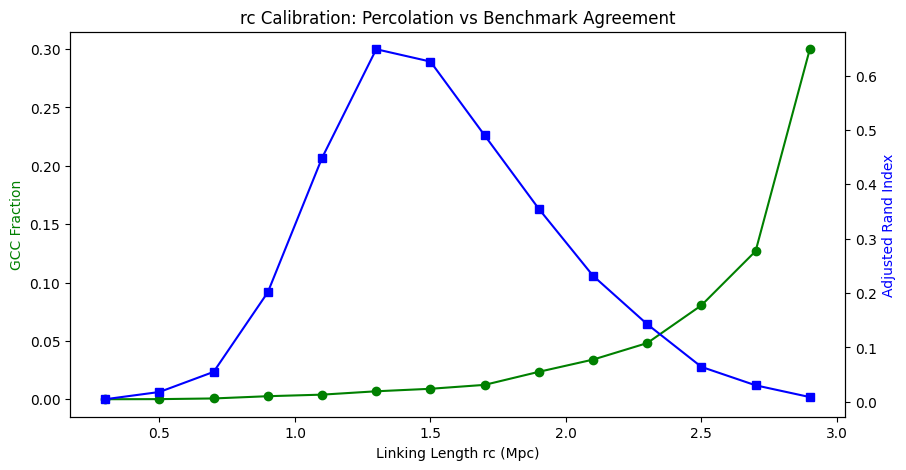

Selected rc for analysis: 1.30 Mpc


In [6]:
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

rc_values = np.arange(0.3, 3.1, 0.2)
percolation_results = []
ari_results = []

true_labels = gal_sample['Grp'].values
eval_mask = gal_sample['eval_mask'].values

print("Scanning rc values...")
for rc in rc_values:
    G_unweighted, _ = build_graphs(coords, rc)
    
    # Percolation stats
    comps = sorted(nx.connected_components(G_unweighted), key=len, reverse=True)
    f_giant = len(comps[0]) / len(coords)
    
    # ARI calculation on evaluation subset
    pred_labels = np.zeros(len(coords), dtype=int)
    for gid, comp in enumerate(comps):
        for node in comp: pred_labels[node] = gid
        
    ari = adjusted_rand_score(true_labels[eval_mask], pred_labels[eval_mask])
    
    percolation_results.append(f_giant)
    ari_results.append(ari)
    print(f"rc={rc:.1f} | f_giant={f_giant:.3f} | ARI={ari:.3f}")

# Plotting diagnostics
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(rc_values, percolation_results, 'g-o', label='GCC Fraction')
ax2.plot(rc_values, ari_results, 'b-s', label='ARI (Benchmark Recovery)')

ax1.set_xlabel('Linking Length rc (Mpc)')
ax1.set_ylabel('GCC Fraction', color='g')
ax2.set_ylabel('Adjusted Rand Index', color='b')
plt.title("rc Calibration: Percolation vs Benchmark Agreement")
plt.show()

optimal_rc = rc_values[np.argmax(ari_results)]
print(f"Selected rc for analysis: {optimal_rc:.2f} Mpc")

## Phase 4: Community Detection

We run three methods using the optimal $r_c$:
1. **Connected Components (CC)** - FoF Baseline
2. **Louvain** (Weighted)
3. **Leiden** (Weighted)

In [7]:
import community as louvain_module
import leidenalg
import igraph as ig

G_eps, G_weight = build_graphs(coords, optimal_rc)

# 1. Connected Components
comps = list(nx.connected_components(G_eps))
labels_cc = np.zeros(len(coords), dtype=int)
for gid, comp in enumerate(comps):
    for node in comp: labels_cc[node] = gid

# 2. Louvain
partition_louvain = louvain_module.best_partition(G_weight, weight='weight')
labels_louvain = np.array([partition_louvain[i] for i in range(len(coords))])

# 3. Leiden
G_ig = ig.Graph.from_networkx(G_weight)
partition_leiden = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition, weights='weight')
labels_leiden = np.array(partition_leiden.membership)

print("Community detection complete.")

Community detection complete.


## Phase 5: Validation and Metric Analysis

We compare the three methods against the Tempel catalog labels on the evaluation subset ($N_{gal} \ge 3$).

In [8]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score

t = true_labels[eval_mask]
results_metrics = []

for name, pred in [('FoF/CC', labels_cc), ('Louvain', labels_louvain), ('Leiden', labels_leiden)]:
    p = pred[eval_mask]
    ari = adjusted_rand_score(t, p)
    nmi = normalized_mutual_info_score(t, p)
    ami = adjusted_mutual_info_score(t, p)
    results_metrics.append({'Method': name, 'ARI': ari, 'NMI': nmi, 'AMI': ami})

metrics_df = pd.DataFrame(results_metrics)
print("Validation Summary:")
print(metrics_df)

Validation Summary:
    Method       ARI       NMI       AMI
0   FoF/CC  0.648580  0.934352  0.725699
1  Louvain  0.412980  0.932334  0.713138
2   Leiden  0.403492  0.932137  0.712008


### Completeness vs Purity Analysis

We calculate how many members of a true group stay together (Completeness) and how many members of a detected community belong to the same true group (Purity).

In [9]:
from collections import Counter

def get_purity_completeness(true, pred):
    # Completeness
    completeness = []
    unique_true = np.unique(true)
    for ut in unique_true:
        mask = (true == ut)
        preds_for_group = pred[mask]
        most_common = Counter(preds_for_group).most_common(1)[0][1]
        completeness.append(most_common / len(preds_for_group))
        
    # Purity
    purity = []
    unique_pred = np.unique(pred)
    for up in unique_pred:
        mask = (pred == up)
        trues_for_comm = true[mask]
        most_common = Counter(trues_for_comm).most_common(1)[0][1]
        purity.append(most_common / len(trues_for_comm))
        
    return np.mean(completeness), np.mean(purity)

print("Mean Completeness and Purity for Leiden:")
c, p = get_purity_completeness(t, labels_leiden[eval_mask])
print(f"Completeness: {c:.3f} | Purity: {p:.3f}")

Mean Completeness and Purity for Leiden:
Completeness: 0.682 | Purity: 0.971


## Phase 6: Network Feature Analysis

We test if weighted degree and local clustering coefficients distinguish group members from field galaxies.

Computing network features...


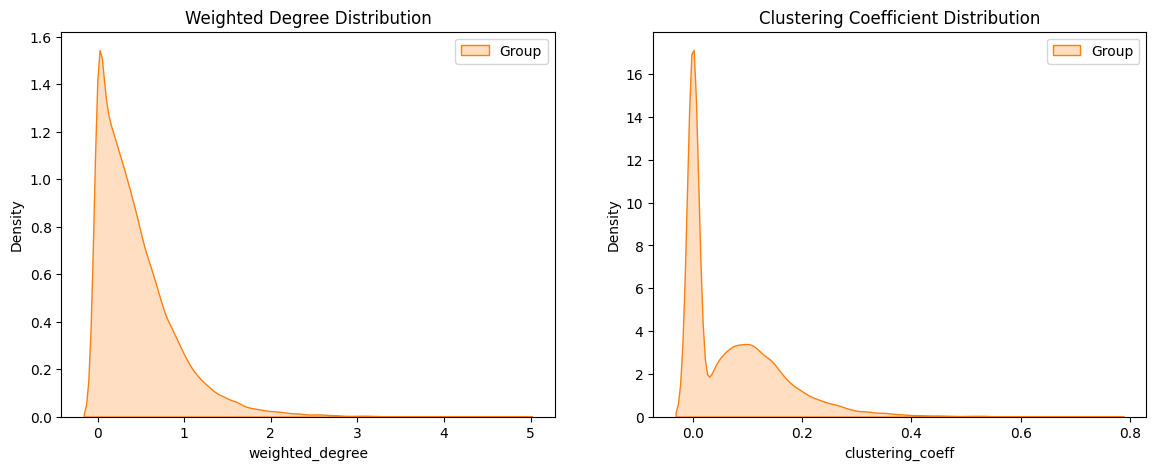

KS Test (Degree) p-value: nan


/var/folders/t9/wl57qdf93xzg4df479bqp9_w0000gn/T/ipykernel_10034/3479806953.py:30: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_val = ks_2samp(gal_sample.loc[field_mask, 'weighted_degree'], gal_sample.loc[group_mask, 'weighted_degree'])


In [10]:
import seaborn as sns
from scipy.stats import ks_2samp

# 1. Compute Features
print("Computing network features...")
weighted_degrees = dict(G_weight.degree(weight='weight'))
clustering_coeffs = nx.clustering(G_weight, weight='weight')

gal_sample['weighted_degree'] = [weighted_degrees[i] for i in range(len(gal_sample))]
gal_sample['clustering_coeff'] = [clustering_coeffs[i] for i in range(len(gal_sample))]

# 2. Analysis: Field (Ngal==1) vs Group (Ngal>=3)
field_mask = gal_sample['Ngal'] == 1
group_mask = gal_sample['eval_mask']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(gal_sample.loc[field_mask, 'weighted_degree'], ax=axes[0], label='Field', fill=True)
sns.kdeplot(gal_sample.loc[group_mask, 'weighted_degree'], ax=axes[0], label='Group', fill=True)
axes[0].set_title("Weighted Degree Distribution")
axes[0].legend()

sns.kdeplot(gal_sample.loc[field_mask, 'clustering_coeff'], ax=axes[1], label='Field', fill=True)
sns.kdeplot(gal_sample.loc[group_mask, 'clustering_coeff'], ax=axes[1], label='Group', fill=True)
axes[1].set_title("Clustering Coefficient Distribution")
axes[1].legend()

plt.show()

ks_stat, p_val = ks_2samp(gal_sample.loc[field_mask, 'weighted_degree'], gal_sample.loc[group_mask, 'weighted_degree'])
print(f"KS Test (Degree) p-value: {p_val:.3e}")

## Final Output

We save the results for the final catalog and potential visualization.

In [13]:
from pathlib import Path

gal_sample['pred_cc'] = labels_cc
gal_sample['pred_louvain'] = labels_louvain
gal_sample['pred_leiden'] = labels_leiden

output_cols = ['objID', 'RAJ2000', 'DEJ2000', 'z', 'X', 'Y', 'Z', 'Grp', 'Ngal', 
               'pred_cc', 'pred_louvain', 'pred_leiden', 'weighted_degree', 'clustering_coeff']
output_cols = ['GalID', 'RAJ2000', 'DEJ2000', 'z', 'X', 'Y', 'Z', 'Grp', 'Ngal', 
               'pred_cc', 'pred_louvain', 'pred_leiden', 'weighted_degree', 'clustering_coeff']
output_path = Path("CWN_Final_Results.csv")
gal_sample[output_cols].to_csv(output_path, index=False)
print("Final results saved to CWN_Final_Results.csv.")

Final results saved to CWN_Final_Results.csv.
